In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

cust_df = pd.read_csv("santander-customer-satisfaction/train.csv", encoding='cp949')

In [97]:
cust_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 370 entries, var3 to TARGET
dtypes: float64(111), int64(259)
memory usage: 214.6 MB


In [ ]:
# # 이상치 처리 (-999999를 가장 빈번한 값인 2로 대체)
# cust_df['var3'].replace(-999999, 2, inplace=True)

# # 변별력 없는 ID 컬럼 제거
# if 'ID' in cust_df.columns:
#     cust_df.drop('ID', axis=1, inplace=True)

# # 피처와 타겟 분리
# X_features = cust_df.iloc[:, :-1]
# y_labels = cust_df.iloc[:, -1]

# print(f"전처리 전 원본 피처 개수: {X_features.shape[1]}")


# # 2. [피처 엔지니어링 ①] 분산이 0인 피처 제거 (Zero Variance)
# # 모든 행의 값이 동일하여 분산이 0인 피처를 찾아 냅니다.
# variance_zero_cols = [col for col in X_features.columns if X_features[col].var() == 0]
# X_features.drop(columns=variance_zero_cols, inplace=True)
# print(f"1. 분산 0 제거 후 피처 개수: {X_features.shape[1]} (제거된 피처 수: {len(variance_zero_cols)})")


# # 3. [피처 엔지니어링 ②] 중복된 피처 제거 (Duplicated Features)
# # 동일한 값을 가진 중복 피처 중 하나만 남기고 제거합니다.
# duplicated_cols = X_features.T.duplicated()[X_features.T.duplicated()].index.tolist()
# X_features.drop(columns=duplicated_cols, inplace=True)
# print(f"2. 중복 피처 제거 후 피처 개수: {X_features.shape[1]} (제거된 피처 수: {len(duplicated_cols)})")


# # 4. [피처 엔지니어링 ③] 희소 피처 제거 (Sparse Features - 99% 이상이 0인 피처)
# # 데이터의 99% 이상이 0으로 채워진 피처들을 찾아 제거합니다.
# # 희소 피처를 제거하지 않아도 auc 값은 별 문제가 없다. 
# num_rows = X_features.shape[0]
# sparse_cols = [col for col in X_features.columns if (X_features[col] == 0).sum() / num_rows >= 0.99]
# X_features.drop(columns=sparse_cols, inplace=True)
# print(f"3. 희소 피처(99%가 0) 제거 후 최종 피처 개수: {X_features.shape[1]} (제거된 피처 수: {len(sparse_cols)})")


# # 5. 데이터 분할 (불균형 데이터이므로 stratify 설정)
# X_train, X_test, y_train, y_test = train_test_split(
#     X_features, y_labels, test_size=0.2, random_state=0, stratify=y_labels
# )

전처리 전 원본 피처 개수: 369
1. 분산 0 제거 후 피처 개수: 335 (제거된 피처 수: 34)
2. 중복 피처 제거 후 피처 개수: 306 (제거된 피처 수: 29)


In [ ]:
# # n_estimators는 500으로, learning_rate 0.05, random state는 예제 수행 시마다 동일 예측 결과를 위해 설정.
# xgb_clf = XGBClassifier(n_estimators=500, 
#                         learning_rate=0.05, 
#                         early_stopping_rounds=100,
#                         eval_metric='auc',
#                         random_state=156)

In [ ]:
# xgb_clf.fit(
#     X_train, y_train,  
#     eval_set=[(X_train, y_train), (X_test, y_test)], 
   
#     verbose=False
# )


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",100
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
# # 1(불만족)에 대한 예측 확률 추출 후 ROC-AUC 계산
# xgb_pred_proba = xgb_clf.predict_proba(X_test)[:, 1]
# xgb_roc_score = roc_auc_score(y_test, xgb_pred_proba)

In [ ]:
# print("\n" + "="*40)
# print(f'최종 전처리 반영 후 XGBoost ROC-AUC Score: {xgb_roc_score:.4f}')
# print("="*40)


최종 전처리 반영 후 XGBoost ROC-AUC Score: 0.8272


In [99]:
# =========================================================================
# 1. 데이터 로드 및 타겟 분포 확인
# =========================================================================


print("=== [1] 원본 데이터 형태 ===")
print(f"Shape: {cust_df.shape}")
target_counts = cust_df['TARGET'].value_counts(normalize=True) * 100
print(f"만족 고객(0): {target_counts[0]:.2f}%, 불만족 고객(1): {target_counts[1]:.2f}%\n")

# 식별자 ID 제거
if 'ID' in cust_df.columns:
    cust_df.drop('ID', axis=1, inplace=True)

X_features = cust_df.iloc[:, :-1]
y_labels = cust_df.iloc[:, -1]


# =========================================================================
# 2. 논문 가이드라인 전처리 (분산 0, 중복, 희소 피처 제거)
# =========================================================================
print("=== [2] 논문 기준 피처 필터링 ===")
# ① Zero Variance 제거
variance_zero_cols = [col for col in X_features.columns if X_features[col].var() == 0]
X_features.drop(columns=variance_zero_cols, inplace=True)
print(f"1. Zero Variance 제거 후 피처 수: {X_features.shape[1]} (제거: {len(variance_zero_cols)}개)")

# ② 중복 피처 제거 (12개 중 정확히 절반인 6개 세트 제거 효과와 동일)
duplicated_cols = X_features.T.duplicated()[X_features.T.duplicated()].index.tolist()
X_features.drop(columns=duplicated_cols, inplace=True)
print(f"2. 중복 피처 제거 후 피처 수: {X_features.shape[1]} (제거: {len(duplicated_cols)}개)")

# ③ 희소 특징 제거 (99% 이상이 0으로 채워진 값)
# shape[0]으로 정확한 전체 행 수를 분모로 지정합니다.
num_rows = X_features.shape[0]
sparse_cols = [col for col in X_features.columns if (X_features[col] == 0).sum() / num_rows >= 0.99]
X_features.drop(columns=sparse_cols, inplace=True)
print(f"3. 희소 피처(99%가 0) 제거 후 피처 수: {X_features.shape[1]} (제거: {len(sparse_cols)}개)")
print("-> 논문 플로우를 거쳐 최종 정제된 피처 개수 확보 완료\n")

=== [1] 원본 데이터 형태 ===
Shape: (76020, 371)
만족 고객(0): 96.04%, 불만족 고객(1): 3.96%

=== [2] 논문 기준 피처 필터링 ===
1. Zero Variance 제거 후 피처 수: 335 (제거: 34개)
2. 중복 피처 제거 후 피처 수: 306 (제거: 29개)
3. 희소 피처(99%가 0) 제거 후 피처 수: 143 (제거: 163개)
-> 논문 플로우를 거쳐 최종 정제된 피처 개수 확보 완료



=== [3] 변수 정밀 분석 및 피처 엔지니어링 ===
var15 파생 피처 생성 완료 (23세 미만 여부)


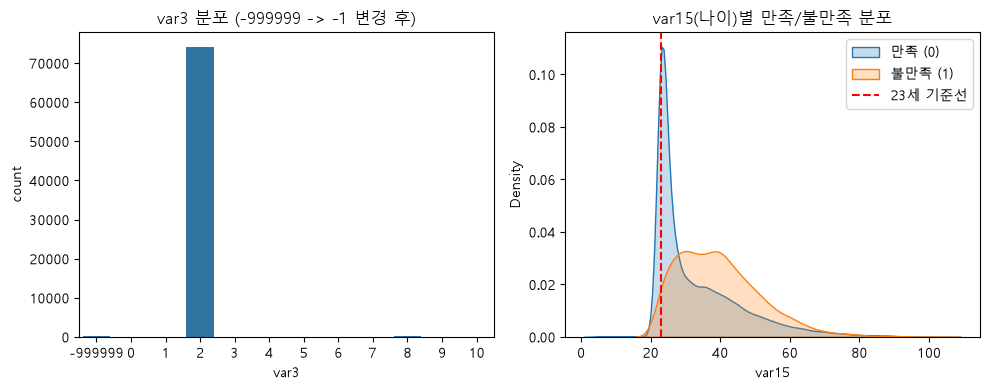

In [ ]:
# =========================================================================
# 3. 주요 변수 분석 및 파생 피처 생성 (var3, var15, var38)
# =========================================================================
import matplotlib.pyplot as plt
import platform

print("=== [3] 변수 정밀 분석 및 피처 엔지니어링 ===")

# --- var3 처리 (이상치 점진적 검증 후 대체) ---
# 처음에 -999999에서 -1로 바꾸어 미미한 비중(3%)을 시각적으로 확인
X_features['var3'].replace(-999999, -1, inplace=True)

# [시각화 1] var3 분포 확인 (-1의 미미함 확인용)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='var3', data=X_features[X_features['var3'] <= 10])
plt.title("var3 분포 (-999999 -> -1 변경 후)")

# 확인 후 가장 흔한 고유값인 2로 최종 변경
X_features['var3'].replace(-1, 2, inplace=True)


# --- var15 처리 (나이 변수 분석 및 파생 피처 추가) ---
# 23살 미만은 항상 만족(TARGET=0)이라는 특성을 반영해 새로운 바이너리 피처 생성
# 설명: 병렬 배치 함으로써 수학적 오답 확률이 0%인 무결점 영역을 확정 짓는다.  ROC-AUC 점수가 즉각적 상승
X_features['var15_under_23'] = np.where(X_features['var15'] < 23, 1, 0)
print(f"var15 파생 피처 생성 완료 (23세 미만 여부)")


# [시각화 2] var15 나이별 불만족 비율 확인
plt.subplot(1, 2, 2)
sns.kdeplot(cust_df[cust_df['TARGET'] == 0]['var15'], label='만족 (0)', shade=True)
sns.kdeplot(cust_df[cust_df['TARGET'] == 1]['var15'], label='불만족 (1)', shade=True)
plt.axvline(x=23, color='red', linestyle='--', label='23세 기준선')
plt.title("var15(나이)별 만족/불만족 분포")
plt.legend()
plt.tight_layout()
plt.show()

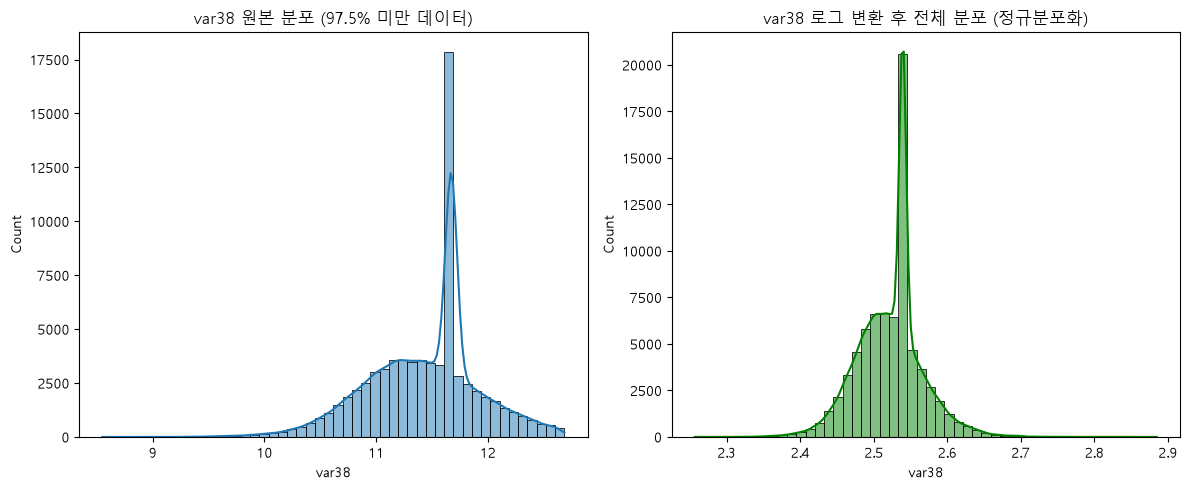

In [103]:

# --- var38 처리 (대출 수치 추정 - 로그 변환 비교셋 준비) ---
# 97.5% 이하 데이터만 슬라이싱하여 지나치기 높은 수치(10만~15만 사이) 시각화로 확인


# 그래프에서 마이너스(-) 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
q_975 = X_features['var38'].quantile(0.975)
var38_filtered = X_features[X_features['var38'] < q_975]['var38']

# [시각화 3] var38 원본(97.5%미만) vs 로그 변환 분포 비교
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(var38_filtered, bins=50, kde=True)
plt.title("var38 원본 분포 (97.5% 미만 데이터)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(X_features['var38']), bins=50, kde=True, color='green')
plt.title("var38 로그 변환 후 전체 분포 (정규분포화)")
plt.tight_layout()
plt.show()

# 머신러닝 성능 비교를 위해 두 가지 버전의 데이터셋 준비
X_features_normal = X_features.copy() # 원본 버전
X_features_log = X_features.copy()    # var38 로그 변환 버전
X_features_log['var38'] = np.log1p(X_features_log['var38'])


In [114]:
# 1. 원본 버전(로그 X) 데이터 분할
X_train_norm, X_test_norm, y_train, y_test = train_test_split(
    X_features_normal, y_labels, test_size=0.2, random_state=156, stratify=y_labels
)

# 2. 로그 변환 버전 데이터 분할 (샘플 조건 통일을 위해 random_state 동일하게 설정)
X_train_log, X_test_log, _, _ = train_test_split(
    X_features_log, y_labels, test_size=0.2, random_state=156, stratify=y_labels
)

# 최신 XGBoost 문법 반영: early_stopping_rounds를 생성자 내부로 이동 🚀
def get_xgb_model():
    return XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=100,  # fit()이 아닌 여기에 배치하여 TypeError 해결!
        eval_metric='auc',          # 평가 지표도 함께 이동
        random_state=156
    )


In [115]:
# -------------------------------------------------------------------------
# ① 원본 var38 데이터셋 학습 및 평가
# -------------------------------------------------------------------------
print("="*60)
print("1. [원본 var38 데이터셋] XGBoost 학습을 시작합니다.")
print("="*60)

xgb_norm = get_xgb_model()
# 최신 버전에서는 fit에 오직 데이터와 eval_set만 전달합니다.
xgb_norm.fit(
    X_train_norm, y_train,
    eval_set=[(X_train_norm, y_train), (X_test_norm, y_test)],
    verbose=False
)

norm_pred_proba = xgb_norm.predict_proba(X_test_norm)[:, 1]
auc_normal = roc_auc_score(y_test, norm_pred_proba)


1. [원본 var38 데이터셋] XGBoost 학습을 시작합니다.


In [116]:
# -------------------------------------------------------------------------
# ② 로그 변환 var38 데이터셋 학습 및 평가
# -------------------------------------------------------------------------
print("\n" + "="*60)
print("2. [로그 변환 var38 데이터셋] XGBoost 학습을 시작합니다.")
print("="*60)

xgb_log = get_xgb_model()
xgb_log.fit(
    X_train_log, y_train,
    eval_set=[(X_train_log, y_train), (X_test_log, y_test)],
    verbose=False
)

log_pred_proba = xgb_log.predict_proba(X_test_log)[:, 1]
auc_log = roc_auc_score(y_test, log_pred_proba)


2. [로그 변환 var38 데이터셋] XGBoost 학습을 시작합니다.


In [117]:
# =========================================================================
# 최종 결과 대조 및 논문 검증 확인
# =========================================================================
print("\n" + "=[ 최종 분석 및 실험 결과 ]" + "="*30)
print(f"  - var38 원본(로그 적용 전) 단일 AUC 점수 : {auc_normal:.4f}")
print(f"  - var38 로그 트랜스포메이션 적용 후 AUC 점수: {auc_log:.4f}")
print("-"*57)
print(f"  - 로그 변환을 통한 실질적 성능 개선 폭  : {auc_log - auc_normal:+.4f}")
print("="*57)

if auc_log > auc_normal:
    print("📢 결론: 논문 저자의 주장대로 정규분포화(Log Transformation)를 적용했을 때 모델 성능이 향상되었습니다.")
else:
    print("📢 결론: 단일 검증 세트 기준으로는 점수 차이가 미미하거나 비슷합니다. (교차 검증 시 편차가 줄어들 수 있습니다.)")


=[ 최종 분석 및 실험 결과 ]==============================
  - var38 원본(로그 적용 전) 단일 AUC 점수 : 0.8513
  - var38 로그 트랜스포메이션 적용 후 AUC 점수: 0.8513
---------------------------------------------------------
  - 로그 변환을 통한 실질적 성능 개선 폭  : +0.0000
📢 결론: 단일 검증 세트 기준으로는 점수 차이가 미미하거나 비슷합니다. (교차 검증 시 편차가 줄어들 수 있습니다.)


In [101]:
# 현재 올려주신 코드의 [5번 데이터 분할] 단계 직후에 아래처럼 대조군을 만듭니다.

# 1. 원본 버전 (현재 쪼개진 X_train, X_test 그대로 사용)
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

# 2. 로그 변환 버전 (똑같이 쪼개진 데이터 내부의 var38만 로그 변환) 🚀
X_train_log = X_train.copy()
X_test_log = X_test.copy()

X_train_log['var38'] = np.log1p(X_train_log['var38'])
X_test_log['var38'] = np.log1p(X_test_log['var38'])

# 3. 이제 동일한 xgb_clf 파라미터로 두 데이터셋을 각각 학습시켜 AUC를 비교하면
# 시드값 편차 없이 오직 '로그 변환'만의 순수한 성능 차이를 확인할 수 있습니다.

In [102]:
# 1. var38에서 가장 압도적인 빈도를 자랑하는 값(최빈값)을 찾습니다. (약 117310.97)
var38_most_frequent = X_features['var38'].value_counts().idxmax()

# 2. 값이 정확히 그 최빈값(빌딩 구간)에 해당하는지 여부를 0과 1로 나타내는 새 피처 생성
X_features['var38_is_most_frequent'] = np.where(X_features['var38'] == var38_most_frequent, 1, 0)

# 3. 그 다음 기존 논문 가이드대로 전체 var38에 로그 변환을 적용합니다.
X_features['var38'] = np.log1p(X_features['var38'])

print(f"-> var38 빌딩 구간 전용 플래그 피처 추가 완료!")

-> var38 빌딩 구간 전용 플래그 피처 추가 완료!
